In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

100%|██████████| 9.91M/9.91M [00:00<00:00, 20.3MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 497kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.71MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 9.06MB/s]


Epoch : 1
Loss: 190.04317978515624
Epoch : 2
Loss: 167.99800048828126
Epoch : 3
Loss: 163.65596100260416
Epoch : 4
Loss: 161.56465288085937
Epoch : 5
Loss: 160.02124895833333
Epoch : 6
Loss: 158.55215224609375
Epoch : 7
Loss: 157.28578372395833
Epoch : 8
Loss: 156.19137861328124
Epoch : 9
Loss: 155.2930085123698
Epoch : 10
Loss: 154.4360668294271
Epoch : 11
Loss: 153.78847431640625
Epoch : 12
Loss: 153.21057547200522
Epoch : 13
Loss: 152.72544978841145
Epoch : 14
Loss: 152.27349622395835
Epoch : 15
Loss: 151.82891184895834
Epoch : 16
Loss: 151.42626640625
Epoch : 17
Loss: 151.1782855794271
Epoch : 18
Loss: 150.76124026692708
Epoch : 19
Loss: 150.49118876953125
Epoch : 20
Loss: 150.22464116210938


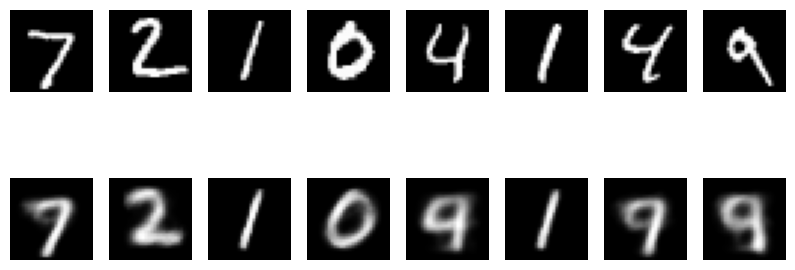

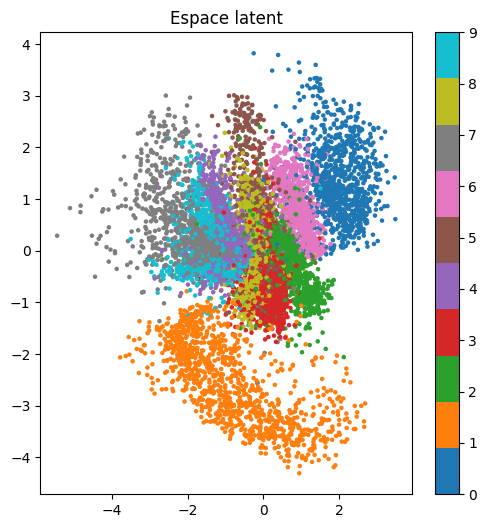

In [2]:
"""
TP : Variational Autoencoder (VAE) sur MNIST
Master 2 Data Science

Ce script implémente un Variational Autoencoder complet comprenant :
- Encoder (réseau de neurones)
- Reparameterization trick
- Decoder
- Fonction de perte VAE
- Entraînement sur MNIST
- Visualisation des reconstructions
- Visualisation de l'espace latent

Auteur : implémentation pédagogique fortement commentée
"""




############################################
# 1. PARAMETRES GLOBAUX
############################################

# dimension de l'espace latent
latent_dim = 2

# taille batch
batch_size = 128

# nombre d'époques
epochs = 20

# device (CPU ou GPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


############################################
# 2. CHARGEMENT DES DONNEES MNIST
############################################

transform = transforms.Compose([
    transforms.ToTensor()
])

train_dataset = torchvision.datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = torchvision.datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

test_loader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)


############################################
# 3. DEFINITION DU MODELE VAE
############################################

class VAE(nn.Module):
    """
    Variational Autoencoder
    """

    def __init__(self, latent_dim=2):
        super(VAE, self).__init__()

        ################################
        # ENCODER
        ################################
        self.encoder = nn.Sequential(
            nn.Linear(784, 400),
            nn.ReLU()
        )

        # vecteur moyenne
        self.fc_mu = nn.Linear(400, latent_dim)

        # vecteur log variance
        self.fc_logvar = nn.Linear(400, latent_dim)

        ################################
        # DECODER
        ################################
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 400),
            nn.ReLU(),
            nn.Linear(400, 784),
            nn.Sigmoid()
        )

    ################################
    # ENCODEUR
    ################################
    def encode(self, x):

        h = self.encoder(x)

        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)

        return mu, logvar

    ################################
    # REPARAMETRIZATION TRICK
    ################################
    def reparameterize(self, mu, logvar):

        # sigma = exp(0.5 * logvar)
        std = torch.exp(0.5 * logvar)

        # bruit epsilon ~ N(0,1)
        eps = torch.randn_like(std)

        # z = mu + sigma * epsilon
        z = mu + eps * std

        return z

    ################################
    # DECODER
    ################################
    def decode(self, z):

        return self.decoder(z)

    ################################
    # FORWARD PASS
    ################################
    def forward(self, x):

        mu, logvar = self.encode(x)

        z = self.reparameterize(mu, logvar)

        reconstruction = self.decode(z)

        return reconstruction, mu, logvar


############################################
# 4. FONCTION DE PERTE VAE
############################################

def loss_function(recon_x, x, mu, logvar):

    ################################
    # Reconstruction loss
    ################################

    BCE = nn.functional.binary_cross_entropy(
        recon_x,
        x,
        reduction='sum'
    )

    ################################
    # KL divergence
    ################################

    KLD = -0.5 * torch.sum(
        1 + logvar - mu.pow(2) - logvar.exp()
    )

    return BCE + KLD


############################################
# 5. INITIALISATION MODELE
############################################

model = VAE(latent_dim).to(device)

optimizer = optim.Adam(model.parameters(), lr=1e-3)


############################################
# 6. BOUCLE D'ENTRAINEMENT
############################################

def train():

    model.train()

    total_loss = 0

    for batch_idx, (data, _) in enumerate(train_loader):

        data = data.view(-1, 784).to(device)

        optimizer.zero_grad()

        recon, mu, logvar = model(data)

        loss = loss_function(recon, data, mu, logvar)

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

    print("Loss:", total_loss / len(train_loader.dataset))


############################################
# 7. ENTRAINEMENT GLOBAL
############################################

for epoch in range(epochs):

    print("Epoch :", epoch+1)

    train()


############################################
# 8. VISUALISATION DES RECONSTRUCTIONS
############################################

def show_reconstruction():

    model.eval()

    data, _ = next(iter(test_loader))

    data = data.view(-1, 784).to(device)

    recon, _, _ = model(data)

    data = data.cpu().view(-1,1,28,28)
    recon = recon.cpu().view(-1,1,28,28)

    plt.figure(figsize=(10,4))

    for i in range(8):

        plt.subplot(2,8,i+1)
        plt.imshow(data[i][0], cmap="gray")
        plt.axis("off")

        plt.subplot(2,8,i+9)
        plt.imshow(recon[i][0].detach(), cmap="gray")
        plt.axis("off")

    plt.show()


############################################
# 9. VISUALISATION ESPACE LATENT
############################################

def plot_latent():

    model.eval()

    zs = []
    labels = []

    with torch.no_grad():

        for data, y in test_loader:

            data = data.view(-1,784).to(device)

            mu, logvar = model.encode(data)

            zs.append(mu.cpu())
            labels.append(y)

    zs = torch.cat(zs)
    labels = torch.cat(labels)

    plt.figure(figsize=(6,6))

    plt.scatter(
        zs[:,0],
        zs[:,1],
        c=labels,
        cmap="tab10",
        s=5
    )

    plt.colorbar()
    plt.title("Espace latent")
    plt.show()


############################################
# 10. EXECUTION VISUALISATION
############################################

show_reconstruction()
plot_latent()